**Problem Statement**

Behavioral Segmentation for Targeted Marketing
Statement:

Businesses group customers based on purchasing power to tailor marketing
efforts. Students will generate a 150-row retail dataset featuring Annual_Spending and
Purchase_Frequency. The project involves StandardScaler and the K-Means Clustering
algorithm to identify customer "personas."
Pipeline: Retail Data Synthesis --> StandardScaler --> K-Means --> Elbow Method
Visualization.

1. **Import libraries**

In [543]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

---

2. **Loading DataSet**



In [544]:
df=pd.read_csv("dataset.csv")
df.head()

,Customer_ID,Gender,City,City_Tier,Annual_Income,Annual_Spending,Purchase_Frequency
0,1,Male,Chennai,1.0,4137689.98,1215936.04,39.0
1,2,Male,Jabalpur,3.0,931911.88,193579.04,25.0
2,3,Male,Lucknow,2.0,618834.00,116811.00,39.0
3,4,Male,Chandigarh,2.0,714835.10,230700.98,23.0
4,5,Male,Jaipur,2.0,696769.14,260387.07,24.0


---

3. **Start of EDA**

In [545]:
df.isna().sum()

,0
Customer_ID,0
Gender,0
City,19
City_Tier,17
Annual_Income,17
Annual_Spending,16
Purchase_Frequency,17


- Fill NA Values

In [546]:
df=df.fillna({"Annual_Income":df['Annual_Income'].mean(),"Annual_Spending":df['Annual_Spending'].mean(),"Purchase_Frequency":df['Purchase_Frequency'].mean()})

- Drop not necessary features

In [547]:
df_model=df.drop(columns=["City","City_Tier","Customer_ID","Gender"])
print(f"NA Sum : \n{df_model.isna().sum()}")

NA Sum : 
Annual_Income         0
Annual_Spending       0
Purchase_Frequency    0
dtype: int64


In [548]:
print(f"Head : \n{df_model.head()}")

Head : 
   Annual_Income  Annual_Spending  Purchase_Frequency
0     4137689.98       1215936.04                39.0
1      931911.88        193579.04                25.0
2      618834.00        116811.00                39.0
3      714835.10        230700.98                23.0
4      696769.14        260387.07                24.0


In [549]:
print(f"Info : \n{df_model.info}")

Info : 
<bound method DataFrame.info of      Annual_Income  Annual_Spending  Purchase_Frequency
0     4.137690e+06     1.215936e+06                39.0
1     9.319119e+05     1.935790e+05                25.0
2     6.188340e+05     1.168110e+05                39.0
3     7.148351e+05     2.307010e+05                23.0
4     6.967691e+05     2.603871e+05                24.0
..             ...              ...                 ...
280   8.869762e+05     3.471220e+05                20.0
281   4.412610e+06     1.286316e+06                31.0
282   1.839458e+06     6.063367e+05                31.0
283   5.639567e+06     2.230686e+06                45.0
284   2.191237e+06     1.406039e+05                17.0

[285 rows x 3 columns]>


In [550]:
print(f"Describe : \n{df_model.describe()}")

Describe : 
       Annual_Income  Annual_Spending  Purchase_Frequency
count   2.850000e+02     2.850000e+02          285.000000
mean    2.191237e+06     6.063367e+05           35.388060
std     1.976993e+06     5.408068e+05           18.959523
min     2.500149e+05     6.104098e+04            5.000000
25%     8.246741e+05     2.307010e+05           23.000000
50%     1.631565e+06     4.657309e+05           33.000000
75%     2.448260e+06     7.649111e+05           43.000000
max     1.039397e+07     2.969988e+06          110.000000


In [551]:
print(f"Shape : {df_model.shape}")

Shape : (285, 3)


* **Correlation**

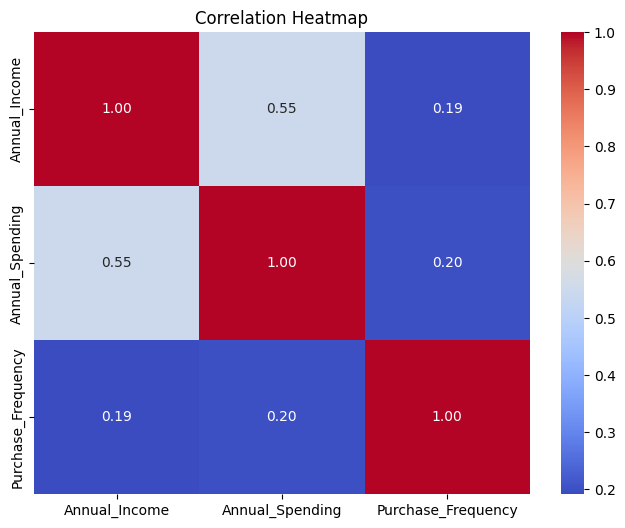

In [552]:
corr = df_model.corr()
plt.figure(figsize=(8, 6))
sb.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

- Outlier Detection

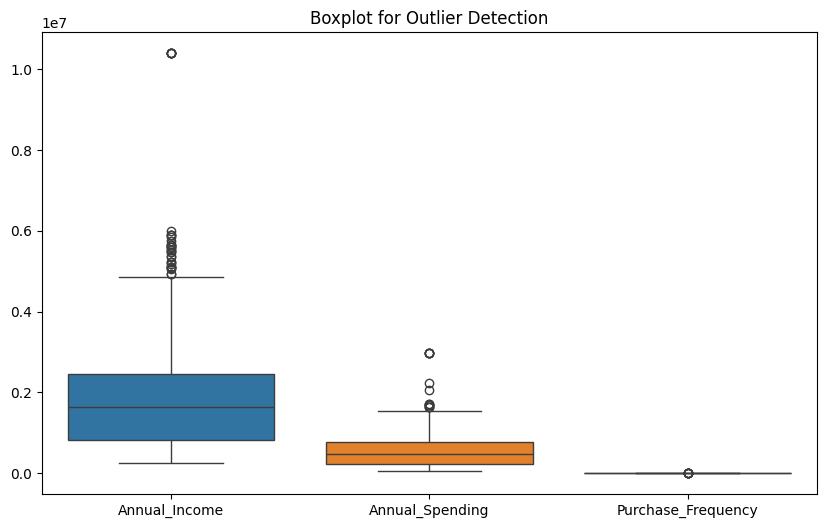

In [553]:
plt.figure(figsize=(10,6))
sb.boxplot(data=df_model)
plt.title("Boxplot for Outlier Detection")
plt.show()

**Apply log transformation**

In [554]:
df_model['Annual_Income'] = np.log1p(df_model['Annual_Income'])
df_model['Annual_Spending'] = np.log1p(df_model['Annual_Spending'])
df_model["Purchase_Frequency"]=np.log1p(df_model["Purchase_Frequency"])

**Check Effectiveness of log transform**

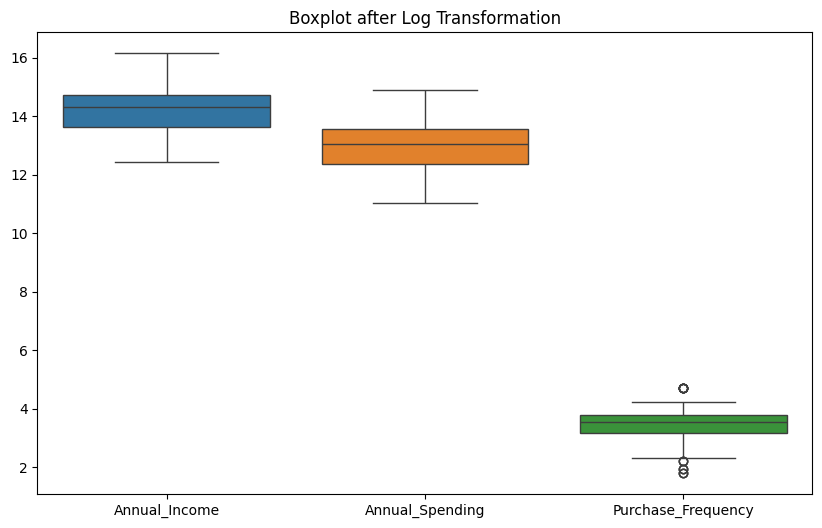

In [555]:
plt.figure(figsize=(10,6))
sb.boxplot(data=df_model)
plt.title("Boxplot after Log Transformation")
plt.show()

- Outlier removal

In [556]:
q1=df_model["Purchase_Frequency"].quantile(0.25)
q3=df_model["Purchase_Frequency"].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
df_model=df_model[(df_model["Purchase_Frequency"]>=lower) & (df_model["Purchase_Frequency"]<=upper)]

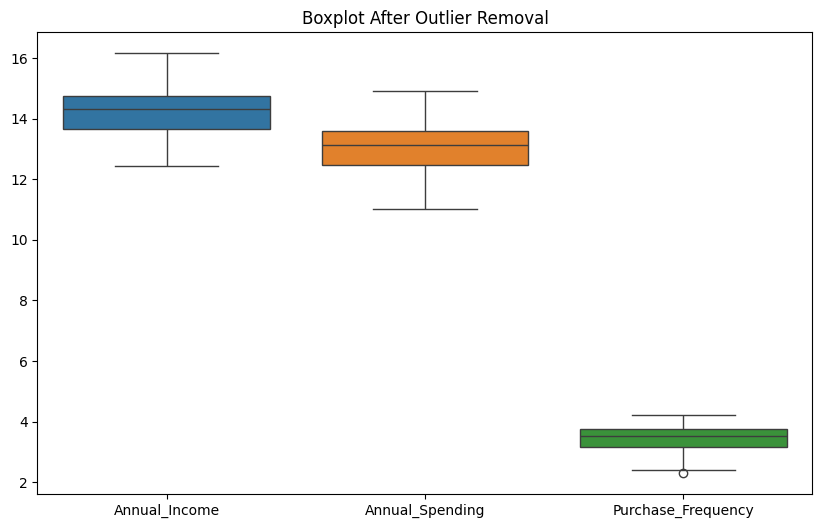

In [557]:
plt.figure(figsize=(10,6))
sb.boxplot(data=df_model)
plt.title("Boxplot After Outlier Removal")
plt.show()

In [558]:
ss = StandardScaler()
x = ss.fit_transform(df_model)

**Elbow Graph**

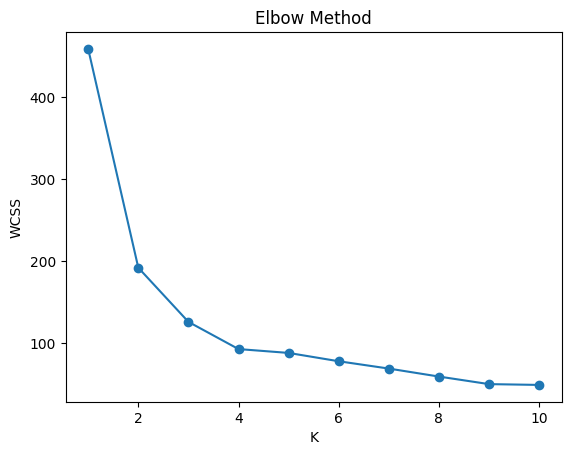

In [559]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_model)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

- Finding Optimal Value of k

In [560]:
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_model)
    print(f"K:{k} -> {silhouette_score(df_model, labels):.3f}")

K:2 -> 0.478
K:3 -> 0.422
K:4 -> 0.422
K:5 -> 0.377
K:6 -> 0.373
K:7 -> 0.388
K:8 -> 0.378
K:9 -> 0.402
K:10 -> 0.363


In [561]:
k=4

Applying KMeans

In [562]:
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_model["Cluster"] = kmeans.fit_predict(df_model)
print(df_model.head())
print("-"*50)
print(df_model.tail())

   Annual_Income  Annual_Spending  Purchase_Frequency  Cluster
0      15.235648        14.011026            3.688879        2
1      13.744995        12.173446            3.258097        3
2      13.335594        11.668321            3.688879        3
3      13.479809        12.348882            3.178054        3
4      13.454211        12.469928            3.218876        3
--------------------------------------------------
     Annual_Income  Annual_Spending  Purchase_Frequency  Cluster
280      13.695575        12.757435            3.044522        3
281      15.299977        14.067294            3.465736        2
282      14.424982        13.315192            3.465736        0
283      15.545318        14.617820            3.828641        2
284      14.599977        11.853709            2.890372        3


In [563]:
print(f"Silhouette Score: {silhouette_score(df_model, df_model["Cluster"]):.2f}")

Silhouette Score: 0.70


Clustering

In [564]:
df_model.groupby("Cluster")[["Annual_Income", "Annual_Spending"]].mean()

,Annual_Income,Annual_Spending
Cluster,,
0,14.421717,13.207683
1,12.682452,11.327484
2,15.335473,14.030281
3,13.639705,12.351870


**Customer Profiling**

In [565]:
clusters = df_model.groupby("Cluster").agg({"Annual_Income": lambda x: np.expm1(x).mean(),"Annual_Spending": lambda x: np.expm1(x).mean()}).reset_index()
clisters=clusters.sort_values(by=["Annual_Income", "Annual_Spending"],ascending=False).reset_index(drop=True)
print(clusters)

   Cluster  Annual_Income  Annual_Spending
0        0   1.870239e+06     5.606768e+05
1        1   3.326059e+05     8.498878e+04
2        2   4.829986e+06     1.343441e+06
3        3   8.904963e+05     2.564287e+05


In [566]:
labels = ["Premium Customers","Low-Value Customers","High-Value Customers","Regular Customers"]
clusters = clusters.sort_values("Cluster").reset_index(drop=True)
clusters["Persona"] = labels

In [567]:
per = dict(zip(clusters["Cluster"], clusters["Persona"]))
df_model["Persona"] = df_model["Cluster"].map(per)
df_model["Persona"].value_counts()

,count
Persona,
Premium Customers,94
Regular Customers,79
High-Value Customers,70
Low-Value Customers,25


**Customer Segmentation Graph**

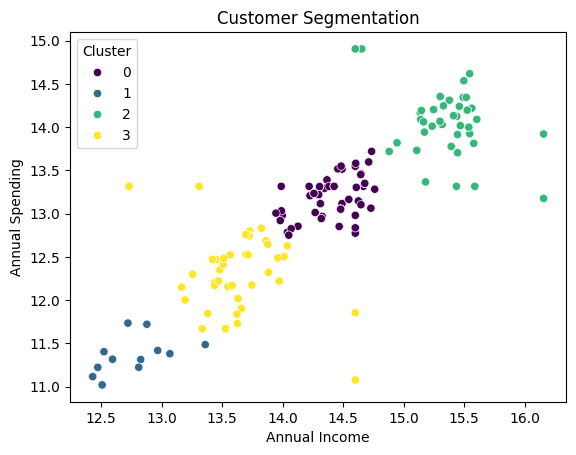

In [568]:
sb.scatterplot(x=df_model["Annual_Income"],y=df_model["Annual_Spending"],hue=df_model["Cluster"],palette="viridis")
plt.title("Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Annual Spending")
plt.show()

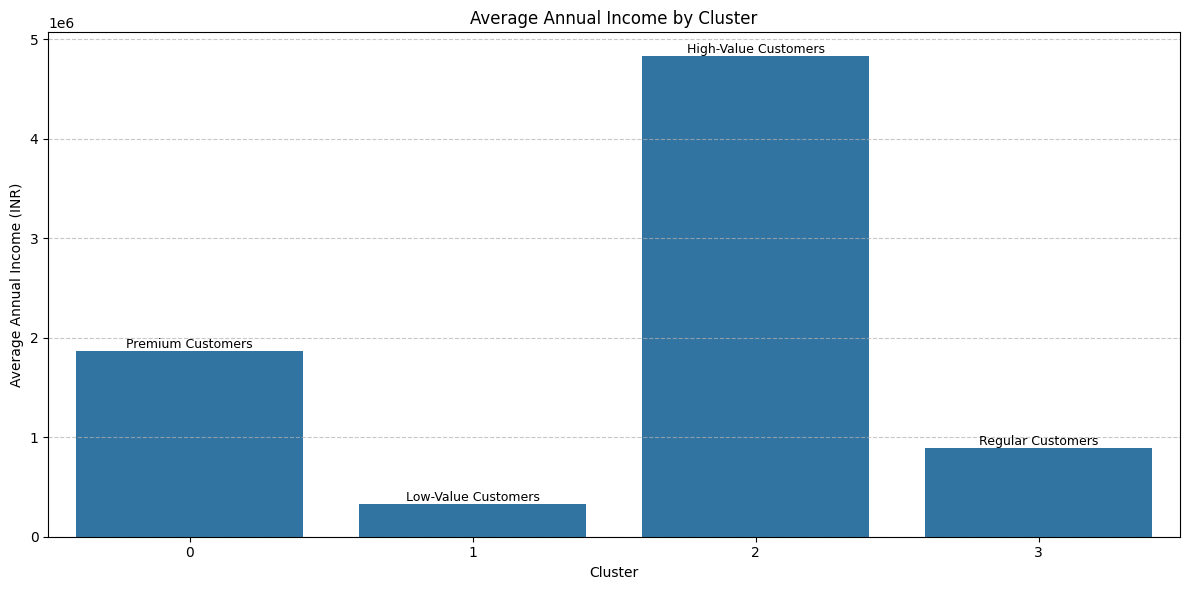

In [569]:
clusters = df_model.groupby("Cluster").agg({"Annual_Spending": lambda x: np.expm1(x).mean(),"Annual_Income": lambda x: np.expm1(x).mean()}).reset_index()
clusters["Persona"] = clusters["Cluster"].map(per)

plt.figure(figsize=(12, 6))
sb.barplot(x="Cluster",y="Annual_Income",data=clusters)

plt.title("Average Annual Income by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Annual Income (INR)")

for i, row in clusters.iterrows():
  plt.text(i,row["Annual_Income"],row["Persona"],ha="center",va="bottom",fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Feature Verification**:

Why `Annual_Income + Annual_Spending` is best

In [570]:
df_verify = df_model.copy()

In [571]:
df_verify["Spending_Score"] = df_verify["Annual_Spending"] / df_verify["Annual_Income"]
candidates = ["Annual_Income", "Annual_Spending", "Purchase_Frequency", "Spending_Score"]

In [572]:
from itertools import combinations
results = []
for combo in combinations(candidates, 2):
    X_test = StandardScaler().fit_transform(df_verify[list(combo)])
    km_test = KMeans(n_clusters=4, random_state=42, n_init=10)
    labels_test = km_test.fit_predict(X_test)
    sil = silhouette_score(X_test, labels_test)
    results.append((combo, sil))

results.sort(key=lambda x: x[1], reverse=True)

In [573]:
print("Feature Pair Comparison (k=4):")
print(f"{"Rank":>4} | {"Silhouette":>10} | Features")
print("-" * 50)
for rank, (feats, sil) in enumerate(results, 1):
    marker = " <-- our choice" if set(feats) == {"Annual_Spending", "Annual_Income"} else ""
    print(f"{rank:>4} | {sil:>10.4f} | {feats[0]} + {feats[1]}{marker}")

Feature Pair Comparison (k=4):
Rank | Silhouette | Features
--------------------------------------------------
   1 |     0.5336 | Annual_Income + Annual_Spending <-- our choice
   2 |     0.4532 | Annual_Income + Spending_Score
   3 |     0.4489 | Purchase_Frequency + Spending_Score
   4 |     0.4052 | Annual_Spending + Spending_Score
   5 |     0.3792 | Annual_Income + Purchase_Frequency
   6 |     0.3700 | Annual_Spending + Purchase_Frequency


In [574]:
print(f"Best pair : {results[0][0]}")

Best pair : ('Annual_Income', 'Annual_Spending')


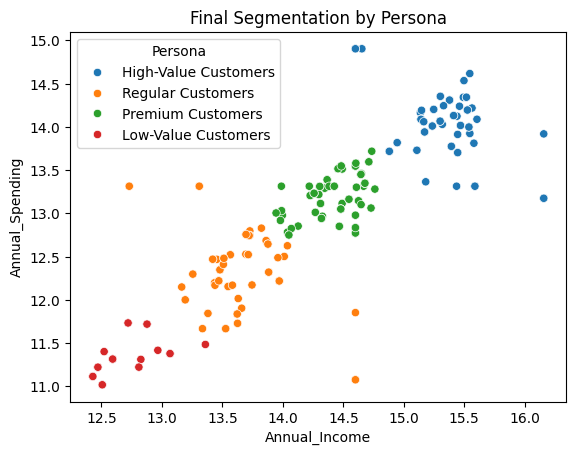

In [577]:
sb.scatterplot(x="Annual_Income", y="Annual_Spending", hue="Persona", data=df_model)
plt.title("Segmentation by Persona")
plt.show()

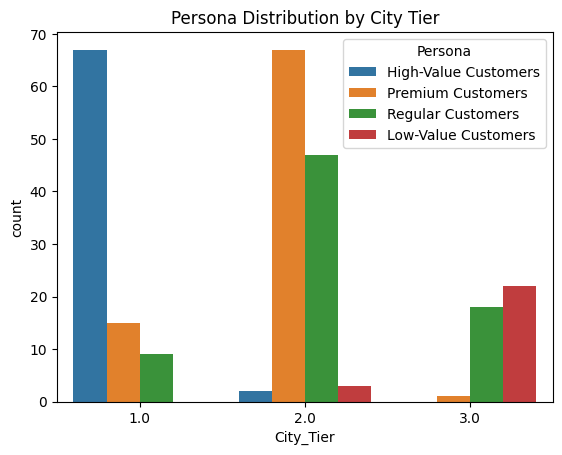

In [580]:
sb.countplot(x=df["City_Tier"], hue=df_model["Persona"])
plt.title("Persona Distribution by City Tier")
plt.show()

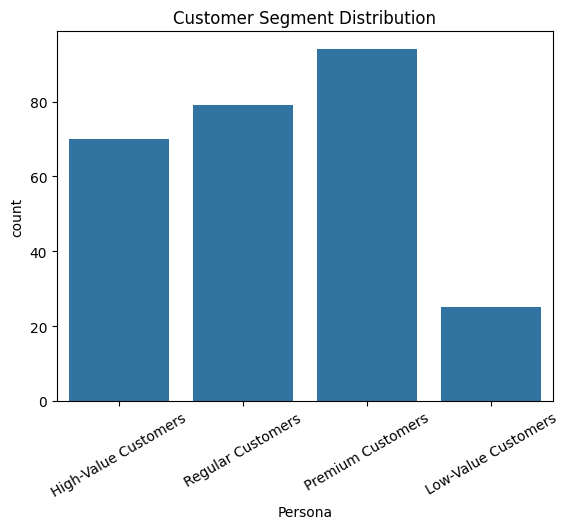

In [588]:
sb.countplot(x="Persona", data=df_model)
plt.title("Customer Segment Distribution")
plt.tick_params(axis='x', rotation=30)
plt.show()